In [1]:
! git branch

* main


In [2]:
import pandas as pd
import numpy as np
import zipfile

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("./"), os.pardir)))

from customFunctions.utils import *
from matplotlib import pyplot as plt

In [3]:
taxa_df = pd.read_csv("data/metazoa_lineage.txt", sep="|", index_col="taxid")[["taxname", "lineage"]]
taxa_df["lineage"] = taxa_df.lineage.str.split(" ")
human_lineage = taxa_df.loc[9606, "lineage"]
taxa_df["block"] = taxa_df.lineage.apply(lambda lineage: np.isin(lineage, human_lineage).sum())
taxa_df["block"] = (taxa_df.block.max()-taxa_df.block)
taxa_df

,taxname,lineage,block
taxid,,,
50794,Cymatogaster aggregata,"[50794, 50792, 50791, 1489909, 1489908, 148987...",18
490246,Ariomma bondi,"[490246, 316124, 316123, 1489894, 1489885, 148...",18
195339,Urolophus aurantiacus,"[195339, 40663, 40662, 1158984, 117851, 117893...",20
229290,Anoplopoma fimbria,"[229290, 229289, 30988, 1490019, 8100, 8111, 1...",18
1078885,Nilssonia nigricans,"[1078885, 227453, 34907, 1579275, 8464, 8459, ...",14
...,...,...,...
3112897,Themus coelestis,"[3112897, 433555, 433502, 41097, 71193, 41087,...",25
360988,Sclerophytum maximum,"[3286427, 3122587, 3122586, 3028843, 6132, 610...",26
199890,Anopheles epiroticus,"[199890, 199889, 44537, 44534, 7164, 43816, 71...",25


In [4]:
taxa_df.groupby("block").size()

block
0        3
2        5
3        2
4       11
5       79
6       97
7        5
8       86
9      407
10     775
11      65
12      49
13       3
14    1535
15     350
16       4
17       2
18    3806
20     223
21      21
23      32
24     138
25    7160
26     321
27      30
dtype: int64

In [5]:
alignments_archive = zipfile.ZipFile('data/alignments.zip', 'r')
alignments_archive

<zipfile.ZipFile filename='data/alignments.zip' mode='r'>

In [6]:
genes = ["MTRNR1", "MTRNR2"]

def _utf8(byte_str):
    return str(byte_str, "utf-8").strip()

def zipped_fasta_to_series(fasta_file, max_void_lines=5):

    sequences_dict = {}
    line = _utf8(fasta_file.readline()) # read first line
    
    # skip possible strange headers, seqrching for first sequence name
    while not line.startswith(">"):
        line = _utf8(fasta_file.readline())
    
    current_name = line[1:] # do (this is a seq name for sure)
    sequences_dict[current_name] = ""
    void_line_count = 0
    while True: # while
        if void_line_count>max_void_lines:
            return pd.Series(sequences_dict)
        line = _utf8(fasta_file.readline())
        if line.startswith(">"):
            current_name = line[1:]
            sequences_dict[current_name] = ""
        elif line:
            sequences_dict[current_name] += line
        else:
            void_line_count += 1
            continue
        void_line_count = 0

rrna_alignment = pd.DataFrame([
    zipped_fasta_to_series(alignments_archive.open('%s.aln'%gene.lower())).rename(gene)
    for gene in genes
]).T.stack().rename("sequence_aln")
rrna_alignment.index.names = ["taxid", "gene"]
rrna_alignment = rrna_alignment.reset_index()
# rrna_alignment["sequence_id"] = rrna_alignment.taxid.str.extract("#(.+)$")[0].values
rrna_alignment[["taxid", "genome"]] = rrna_alignment.taxid.str.extract(r"^(.+)#(.+)\(").values
rrna_alignment.index = rrna_alignment.taxid+"/"+rrna_alignment.gene
rrna_alignment["taxid"] = rrna_alignment["taxid"].astype(int)
rrna_alignment["block"] = taxa_df.loc[rrna_alignment.taxid, "block"].values
rrna_alignment["sequence_aln"] = rrna_alignment["sequence_aln"].str.replace("U", "T")
rrna_alignment

,taxid,gene,sequence_aln,genome,block
50794/MTRNR1,50794,MTRNR1,----------------------------------------------...,AP009128.1,18
490246/MTRNR1,490246,MTRNR1,----------------------------------------------...,OR546171.1,18
195339/MTRNR1,195339,MTRNR1,----------------------------------------------...,OR466415.1,20
229290/MTRNR1,229290,MTRNR1,----------------------------------------------...,JX070112.1,18
1078885/MTRNR1,1078885,MTRNR1,----------------------------------------------...,MG383833.1,14
...,...,...,...,...,...
3112897/MTRNR2,3112897,MTRNR2,----------------------------------------------...,OQ221866.1,25
360988/MTRNR2,360988,MTRNR2,----------------------------------------------...,OL616274.1,26
199890/MTRNR2,199890,MTRNR2,----------------------------------------------...,KT382821.1,25
317752/MTRNR2,317752,MTRNR2,----------------------------------------------...,KY039113.1,25


In [7]:
mithril_df = pd.read_csv(
    "data/mithril_V053.txt",
    sep="\t", low_memory=False, index_col="Mithril_id", na_values="."
)
mithril_df = mithril_df.loc[mithril_df["Molecule_type"]=="rRNA"]
mithril_df = mithril_df.loc[:,~(mithril_df.isna().all())]
mithril_df["gene"] = mithril_df.Gene_symbol.str.replace("-", "")
mithril_df["Gene_position"] = mithril_df["Gene_position"].astype(int)


################################# FIX #################################
# fix for the missing base in mithril variants collection.
# we remove the affected variants from mithril and adjust the Gene_position according to this change

ghost_positions = mithril_df.loc[mithril_df.Ref=="N", ["gene", "Gene_position"]]
display(ghost_positions)
for ghost_id, ghost in ghost_positions.drop_duplicates().iterrows(): # it's just one position
    mithril_df.loc[(mithril_df.gene==ghost.gene) & (mithril_df.Gene_position>ghost.Gene_position), "Gene_position"] -= 1
mithril_df.drop(ghost_positions.index, axis=0, inplace=True)
del ghost_id, ghost, ghost_positions

mithril_df

,gene,Gene_position
Mithril_id,,
MITHRIL.9318,MTRNR2,1437
MITHRIL.9319,MTRNR2,1437
MITHRIL.9320,MTRNR2,1437
MITHRIL.9321,MTRNR2,1437


,Start,Ref,Alt,Molecule_type,Gene_symbol,Extended_annotation,Gene_position,Gene_start,Gene_end,Gene_strand,MLC_score,PhastCons_100V,PhyloP_100V,gene
Mithril_id,,,,,,,,,,,,,,
MITHRIL.1941,648,A,C,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,1,648,1601,+,0.519343,0.016,-1.211,MTRNR1
MITHRIL.1942,648,A,G,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,1,648,1601,+,0.519343,0.016,-1.211,MTRNR1
MITHRIL.1943,648,A,T,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,1,648,1601,+,0.519343,0.016,-1.211,MTRNR1
MITHRIL.1944,649,A,C,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,2,648,1601,+,0.536906,0.984,8.630,MTRNR1
MITHRIL.1945,649,A,G,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,2,648,1601,+,0.536906,0.984,8.630,MTRNR1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,3228,T,C,rRNA,MT-RNR2,mitochondrially encoded 16S rRNA,1557,1671,3229,+,0.681815,0.000,-1.952,MTRNR2
MITHRIL.9684,3228,T,G,rRNA,MT-RNR2,mitochondrially encoded 16S rRNA,1557,1671,3229,+,0.681815,0.000,-1.952,MTRNR2
MITHRIL.9685,3229,T,A,rRNA,MT-RNR2,mitochondrially encoded 16S rRNA,1558,1671,3229,+,0.709337,0.000,-0.833,MTRNR2


In [8]:
print("".join(mithril_df.query("gene=='MTRNR1'").groupby("Gene_position").Ref.first()))
print(rrna_alignment.loc["9606/MTRNR1", "sequence_aln"].replace("-",""))

AATAGGTTTGGTCCTAGCCTTTCTATTAGCTCTTAGTAAGATTACACATGCAAGCATCCCCGTTCCAGTGAGTTCACCCTCTAAATCACCACGATCAAAAGGAACAAGCATCAAGCACGCAGCAATGCAGCTCAAAACGCTTAGCCTAGCCACACCCCCACGGGAAACAGCAGTGATTAACCTTTAGCAATAAACGAAAGTTTAACTAAGCTATACTAACCCCAGGGTTGGTCAATTTCGTGCCAGCCACCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGATACCCCACTATGCTTAGCCCTAAACCTCAACAGTTAAATCAACAAAACTGCTCGCCAGAACACTACGAGCCACAGCTTAAAACTCAAAGGACCTGGCGGTGCTTCATATCCCTCTAGAGGAGCCTGTTCTGTAATCGATAAACCCCGATCAACCTCACCACCTCTTGCTCAGCCTATATACCGCCATCTTCAGCAAACCCTGATGAAGGCTACAAAGTAAGCGCAAGTACCCACGTAAAGACGTTAGGTCAAGGTGTAGCCCATGAGGTGGCAAGAAATGGGCTACATTTTCTACCCCAGAAAACTACGATAGCCCTTATGAAACTTAAGGGTCGAAGGTGGATTTAGCAGTAAACTAAGAGTAGAGTGCTTAGTTGAACAGGGCCCTGAAGCGCGTACACACCGCCCGTCACCCTCCTCAAGTATACTTCAAAGGACATTTAACTAAAACCCCTACGCATTTATATAGAGGAGACAAGTCGTAACATGGTAAGTGTACTGGAAAGTGCACTTGGACGAAC
AATAGGTTTGGTCCTAGCCTTTCTATTAGCTCTTAGTAAGATTAC

In [9]:
# prove that each gene has continuous Gene_position
mithril_df.groupby("gene").Gene_position.unique().apply(np.diff).apply(np.max)

gene
MTRNR1    1
MTRNR2    1
Name: Gene_position, dtype: int64

In [10]:
# ensure that alignment sequence is the same of mithril
(mithril_df.query("gene=='MTRNR1'").groupby("Gene_position").Ref.first().values\
==\
np.array(list(rrna_alignment.loc["9606/MTRNR1", "sequence_aln"].replace("-","")))).mean()

np.float64(1.0)

In [11]:
# ensure that alignment sequence is the same of mithril
(mithril_df.query("gene=='MTRNR2'").groupby("Gene_position").Ref.first().values\
==\
np.array(list(rrna_alignment.loc["9606/MTRNR2", "sequence_aln"].replace("-","")))).mean()

np.float64(1.0)

In [12]:
# prove that MTRNR2 has a deletion in Mithril genome position because of the N we removed
mithril_df.groupby("gene").Start.unique().apply(np.diff).apply(np.max)

gene
MTRNR1    1
MTRNR2    2
Name: Start, dtype: int64

In [13]:
human_aligned_sequences = rrna_alignment.loc[rrna_alignment.taxid==9606].set_index("gene").sequence_aln
human_aligned_sequences

gene
MTRNR1    ----------------------------------------------...
MTRNR2    ----------------------------------------------...
Name: sequence_aln, dtype: object

In [14]:
human_sequences = human_aligned_sequences.str.replace("-", "")
human_sequences

gene
MTRNR1    AATAGGTTTGGTCCTAGCCTTTCTATTAGCTCTTAGTAAGATTACA...
MTRNR2    GCTAAACCTAGCCCCAAACCCACTCCACCTTACTACCAGACAACCT...
Name: sequence_aln, dtype: object

In [15]:
def alterate_sequence(gene, gene_position, ref_nt, alt_nt):
    
    if ref_nt == alt_nt:
        raise AssertionError("reference nt is equal to alterated nt!")
    
    if human_sequences.loc[gene][gene_position] != ref_nt:
        raise AssertionError(
            "given reference nucleotide is `%s` instead of `%s`!"%(
                ref_nt, human_sequences.loc[gene][gene_position]
            )
        )
    
    seq = human_sequences.loc[gene][:gene_position] + alt_nt + human_sequences.loc[gene][gene_position+1:]
    return seq

print(alterate_sequence("MTRNR2", 2, "T", "N"))
print(human_sequences["MTRNR2"])

GCNAAACCTAGCCCCAAACCCACTCCACCTTACTACCAGACAACCTTAGCCAAACCATTTACCCAAATAAAGTATAGGCGATAGAAATTGAAACCTGGCGCAATAGATATAGTACCGCAAGGGAAAGATGAAAAATTATAACCAAGCATAATATAGCAAGGACTAACCCCTATACCTTCTGCATAATGAATTAACTAGAAATAACTTTGCAAGGAGAGCCAAAGCTAAGACCCCCGAAACCAGACGAGCTACCTAAGAACAGCTAAAAGAGCACACCCGTCTATGTAGCAAAATAGTGGGAAGATTTATAGGTAGAGGCGACAAACCTACCGAGCCTGGTGATAGCTGGTTGTCCAAGATAGAATCTTAGTTCAACTTTAAATTTGCCCACAGAACCCTCTAAATCCCCTTGTAAATTTAACTGTTAGTCCAAAGAGGAACAGCTCTTTGGACACTAGGAAAAAACCTTGTAGAGAGAGTAAAAAATTTAACACCCATAGTAGGCCTAAAAGCAGCCACCAATTAAGAAAGCGTTCAAGCTCAACACCCACTACCTAAAAAATCCCAAACATATAACTGAACTCCTCACACCCAATTGGACCAATCTATCACCCTATAGAAGAACTAATGTTAGTATAAGTAACATGAAAACATTCTCCTCCGCATAAGCCTGCGTCAGATTAAAACACTGAACTGACAATTAACAGCCCAATATCTACAATCAACCAACAAGTCATTATTACCCTCACTGTCAACCCAACACAGGCATGCTCATAAGGAAAGGTTAAAAAAAGTAAAAGGAACTCGGCAAATCTTACCCCGCCTGTTTACCAAAAACATCACCTCTAGCATCACCAGTATTAGAGGCACCGCCTGCCCAGTGACACATGTTTAACGGCCGCGGTACCCTAACCGTGCAAAGGTAGCATAATCACTTGTTCCTTAAATAGGGACCTGTATGAATGGCTCCACGAGGGTTCAGCTGTCTCTTACTTTTAAC

In [16]:
# writing human ungapped atered sequences (one for each mithril variant)

open("checkpoints/altered_sequences.fa", "w").write("\n".join(mithril_df.apply(
    lambda variant:
    ">"+variant.name+"\n"+alterate_sequence(variant.gene, variant.Gene_position-1, variant.Ref, variant.Alt),
    axis=1
)))

10125479

In [17]:
def get_PWM(gene, epsilon=10e-15):
    
    nucleotides = np.array(list('ACGT'))
    
    MSA = np.array(list(rrna_alignment.loc[rrna_alignment.gene==gene, "sequence_aln"].apply(list)))
    PFM = (MSA[:,:,None]==nucleotides).sum(0).T
    PPM = PFM/PFM.sum(0)
    PPM[PPM==0] = epsilon
    PWM = np.log2(PPM/.25)
    
    PWM = pd.DataFrame(PWM, index=nucleotides).T.stack().to_frame().reset_index()
    PWM.columns = ["alignment_position", "alt", "score"]
    PWM["gene"] = gene
    PWM = PWM.set_index(["gene", "alignment_position", "alt"]).score

    return PWM

PWM_score = pd.concat([get_PWM(gene) for gene in rrna_alignment.gene.unique()])
PWM_score

gene    alignment_position  alt
MTRNR1  0                   A       2.000000
                            C     -44.506993
                            G     -44.506993
                            T     -44.506993
        1                   A     -44.506993
                                     ...    
MTRNR2  8452                T     -44.506993
        8453                A     -44.506993
                            C       2.000000
                            G     -44.506993
                            T     -44.506993
Name: score, Length: 54632, dtype: float64

In [18]:
def sequence_features(gene, human_position, ref_nt, alt_nt, debug=False):
    
    if ref_nt == alt_nt:
        raise AssertionError("reference nt is equal to alterated nt!")
    
    human_alignment = rrna_alignment.loc[
        (rrna_alignment.taxid==9606)&(rrna_alignment.gene==gene),
        "sequence_aln"
    ].iloc[0]
    human_alignment = np.array(list(human_alignment))
    human_positions = np.zeros(len(human_alignment))*np.nan
    human_positions[human_alignment!="-"] = np.arange((human_alignment!="-").sum())
    alignment_position = np.argwhere(human_positions==human_position).ravel()[0]
    if human_alignment[alignment_position] != ref_nt:
        raise AssertionError(
            "given reference nucleotide is `%s` instead of `%s`!"%(
                ref_nt, human_alignment[alignment_position]
            )
        )
    del human_alignment, human_positions
    
    sequence_n_block = rrna_alignment.loc[rrna_alignment.gene==gene,["sequence_aln", "block"]]
    nt_series, blocks = sequence_n_block.sequence_aln.str[alignment_position], sequence_n_block.block
    del sequence_n_block

    pwm_score = PWM_score.loc[(gene, alignment_position, alt_nt)]
    
    freq_alt_nt = (nt_series[nt_series!="-"]==alt_nt).mean()
    freq_ref_nt = (nt_series[nt_series!="-"]==ref_nt).mean()
    coverage = (nt_series!="-").mean()
    
    nts = np.array(list("ATGC"))
    epsilon = 10e-16
    
    p = (nt_series.values[None,:]==nts[:,None]).mean(1)
    entropy = -(p*np.log2(p+epsilon)).sum()

    blocks = rrna_alignment.loc[rrna_alignment.gene==gene,"block"]
    conservation = (nt_series==ref_nt).groupby(blocks).all()
    conservation = conservation[~conservation].index.min()
    if np.isnan(conservation):
        conservation = blocks.max()
    
    
    return pd.Series(
        [freq_ref_nt, freq_alt_nt, coverage, entropy, conservation, pwm_score],
        index=["ref_frequency", "alt_frequency", "coverage", "entropy", "conservation_blocks", "PWM_score"]
    )

sequence_features("MTRNR1", 0, "A", "T")

ref_frequency          0.063046
alt_frequency          0.175004
coverage               0.414031
entropy                1.007675
conservation_blocks    5.000000
PWM_score             -0.514311
dtype: float64

In [19]:
complement = {
    "A":"T",
    "T":"A",
    "G":"C",
    "C":"G",
}

ERRORS = []

def sequence_features_wrapper(variant_row, debug=False):
    global ERRORS
    gene, pos = variant_row["gene"], variant_row["Gene_position"]-1,
    if variant_row["Gene_strand"] == "+":
        ref, alt = variant_row["Ref"], variant_row["Alt"]
    else:
        ref, alt = complement[variant_row["Ref"]], complement[variant_row["Alt"]]
    try :
        return sequence_features(gene, pos, ref, alt, debug)
    except:
        ERRORS.append(variant_row.name)
        return None

In [20]:
# 2 min
sequence_features_result = mithril_df.apply(
    sequence_features_wrapper, axis=1
)
sequence_features_result

,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score
Mithril_id,,,,,,
MITHRIL.1941,0.063046,0.734159,0.414031,1.007675,5.0,1.554394
MITHRIL.1942,0.063046,0.027632,0.414031,1.007675,5.0,-3.177276
MITHRIL.1943,0.063046,0.175004,0.414031,1.007675,5.0,-0.514311
MITHRIL.1944,0.943580,0.005642,0.431192,0.690667,5.0,-5.469367
MITHRIL.1945,0.943580,0.020433,0.431192,0.690667,5.0,-3.612731
...,...,...,...,...,...,...
MITHRIL.9683,0.331219,0.227366,0.414689,1.237161,4.0,-0.136909
MITHRIL.9684,0.331219,0.035675,0.414689,1.237161,4.0,-2.808957
MITHRIL.9685,0.643931,0.186358,0.284371,0.908297,3.0,-0.423848


In [21]:
wt_ss = pd.DataFrame([
    entry.split("\n")[:3]
    for entry in open("data/structures/rRNA_homoSapiens_RNAcentralPred.txt").read().split(">")[1:]
], columns=["gene", "sequence", "ss"]).set_index("gene")
wt_ss.sequence = wt_ss.sequence.str.replace("U", "T")
wt_ss

,sequence,ss
gene,,
MTRNR1,AATAGGTTTGGTCCTAGCCTTTCTATTAGCTCTTAGTAAGATTACA...,.....................((((((.(((.((((((((....((...
MTRNR2,GCTAAACCTAGCCCCAAACCCACTCCACCTTACTACCAGACAACCT...,((.....(..((((...................................


In [22]:
# ensure that sequence is the same for both human MSA sequence and predicted structure
wt_ss.sequence==human_aligned_sequences.str.replace("-", "")

gene
MTRNR1    True
MTRNR2    True
dtype: bool

In [23]:
energy_df = [
    rrna.split("\n")
    for rrna in open("data/structures/Mito_rRNA_variant_folded_R2DT_enerFinal.txt").read().split("\n>")
]
energy_df = [
    [*rrna[:2], *rrna[2].split(" ", maxsplit=1)]
    for rrna in energy_df
]
energy_df = pd.DataFrame(energy_df, columns=["gene_or_id", "seq", "ss", "ss_energy"]).set_index("gene_or_id")
energy_df["ss_energy"] = energy_df.ss_energy.str.replace(r"[\(\)]", "", regex=True).astype(float)
energy_df.index = energy_df.index.str.replace(">", "")
energy_df["ss_energy_wt"] = mithril_df.join(energy_df.ss_energy).merge(
    energy_df.ss_energy,
    left_on="gene", right_index=True,
    suffixes=["_variant", "_wt"]
).ss_energy_wt
energy_df["ddG"] = energy_df.ss_energy-energy_df.ss_energy_wt
energy_df["ss_distorsion"] = mithril_df.join(energy_df.ss).merge(
    energy_df.ss,
    left_on="gene", right_index=True,
    suffixes=["_variant", "_wt"]
).apply(
    lambda variant: 1-(np.array(list(variant.ss_variant)) == np.array(list(variant.ss_wt))).mean(),
    axis=1
)
energy_df

,seq,ss,ss_energy,ss_energy_wt,ddG,ss_distorsion
gene_or_id,,,,,,
MTRNR1,AAUAGGUUUGGUCCUAGCCUUUCUAUUAGCUCUUAGUAAGAUUACA...,.....................((((((.(((.((((((((....((...,-123.50,NaN,NaN,NaN
MTRNR2,GCUAAACCUAGCCCCAAACCCACUCCACCUUACUACCAGACAACCU...,((.....(..((((...................................,-97.17,NaN,NaN,NaN
MITHRIL.3389,AAUAGGUUUGGUCCUAGCCUUUCUAUUAGCUCUUAGUAAGAUUACA...,.....................((((((.(((.((((((((....((...,-123.50,-123.50,0.0,0.000000
MITHRIL.3924,AAUAGGUUUGGUCCUAGCCUUUCUAUUAGCUCUUAGUAAGAUUACA...,.....................((((((.(((.((((((((....((...,-118.80,-123.50,4.7,0.002096
MITHRIL.2516,AAUAGGUUUGGUCCUAGCCUUUCUAUUAGCUCUUAGUAAGAUUACA...,.....................((((((.(((.((((((((....((...,-119.60,-123.50,3.9,0.002096
...,...,...,...,...,...,...
MITHRIL.8835,GCUAAACCUAGCCCCAAACCCACUCCACCUUACUACCAGACAACCU...,((.....(..((((...................................,-95.67,-97.17,1.5,0.001284
MITHRIL.7254,GCUAAACCUAGCCCCAAACCCACUCCACCUUACUACCAGACAACCU...,((.....(..((((...................................,-95.17,-97.17,2.0,0.001284
MITHRIL.9167,GCUAAACCUAGCCCCAAACCCACUCCACCUUACUACCAGACAACCU...,((.....(..((((...................................,-94.27,-97.17,2.9,0.000000


In [24]:
energy_df.groupby("ss_energy_wt").ss_distorsion.unique() # quite useless

ss_energy_wt
-123.50     [0.0, 0.002096436058700246]
-97.17     [0.0012836970474967568, 0.0]
Name: ss_distorsion, dtype: object

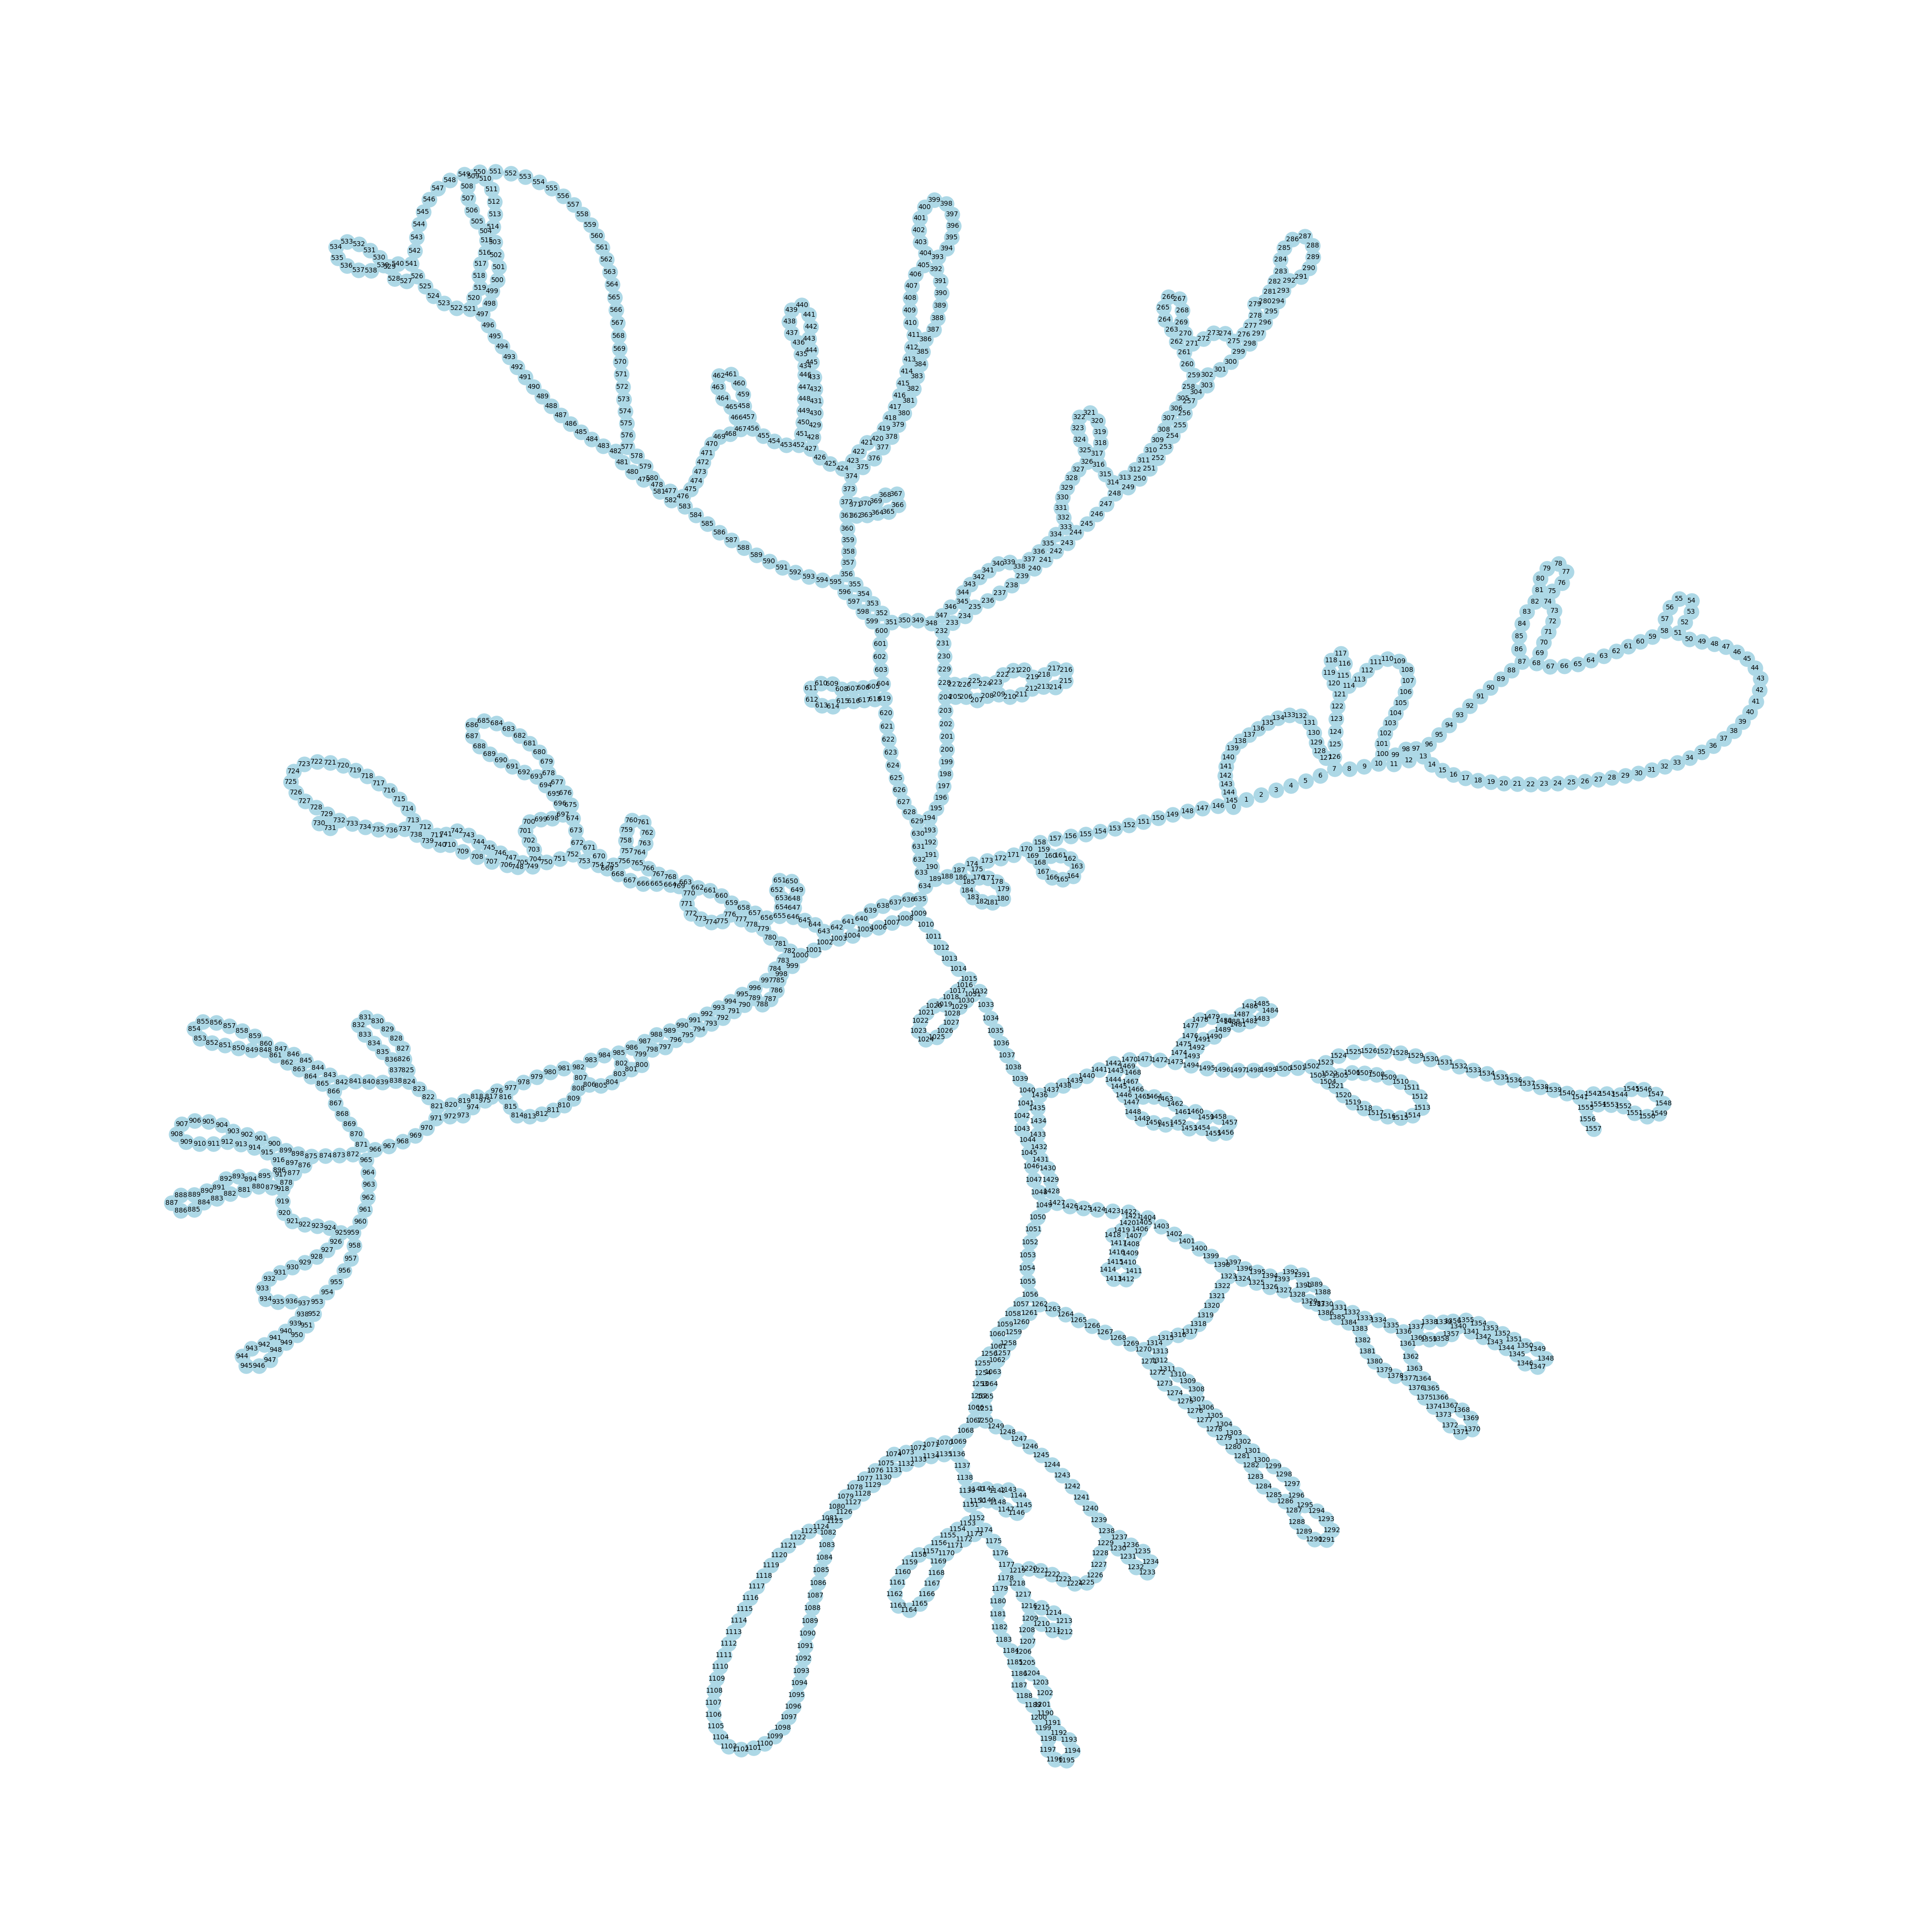

In [25]:
plt.figure(figsize=(40,40))
draw_rna_graph(dot_bracket_to_graph(wt_ss.loc["MTRNR2", "ss"]))

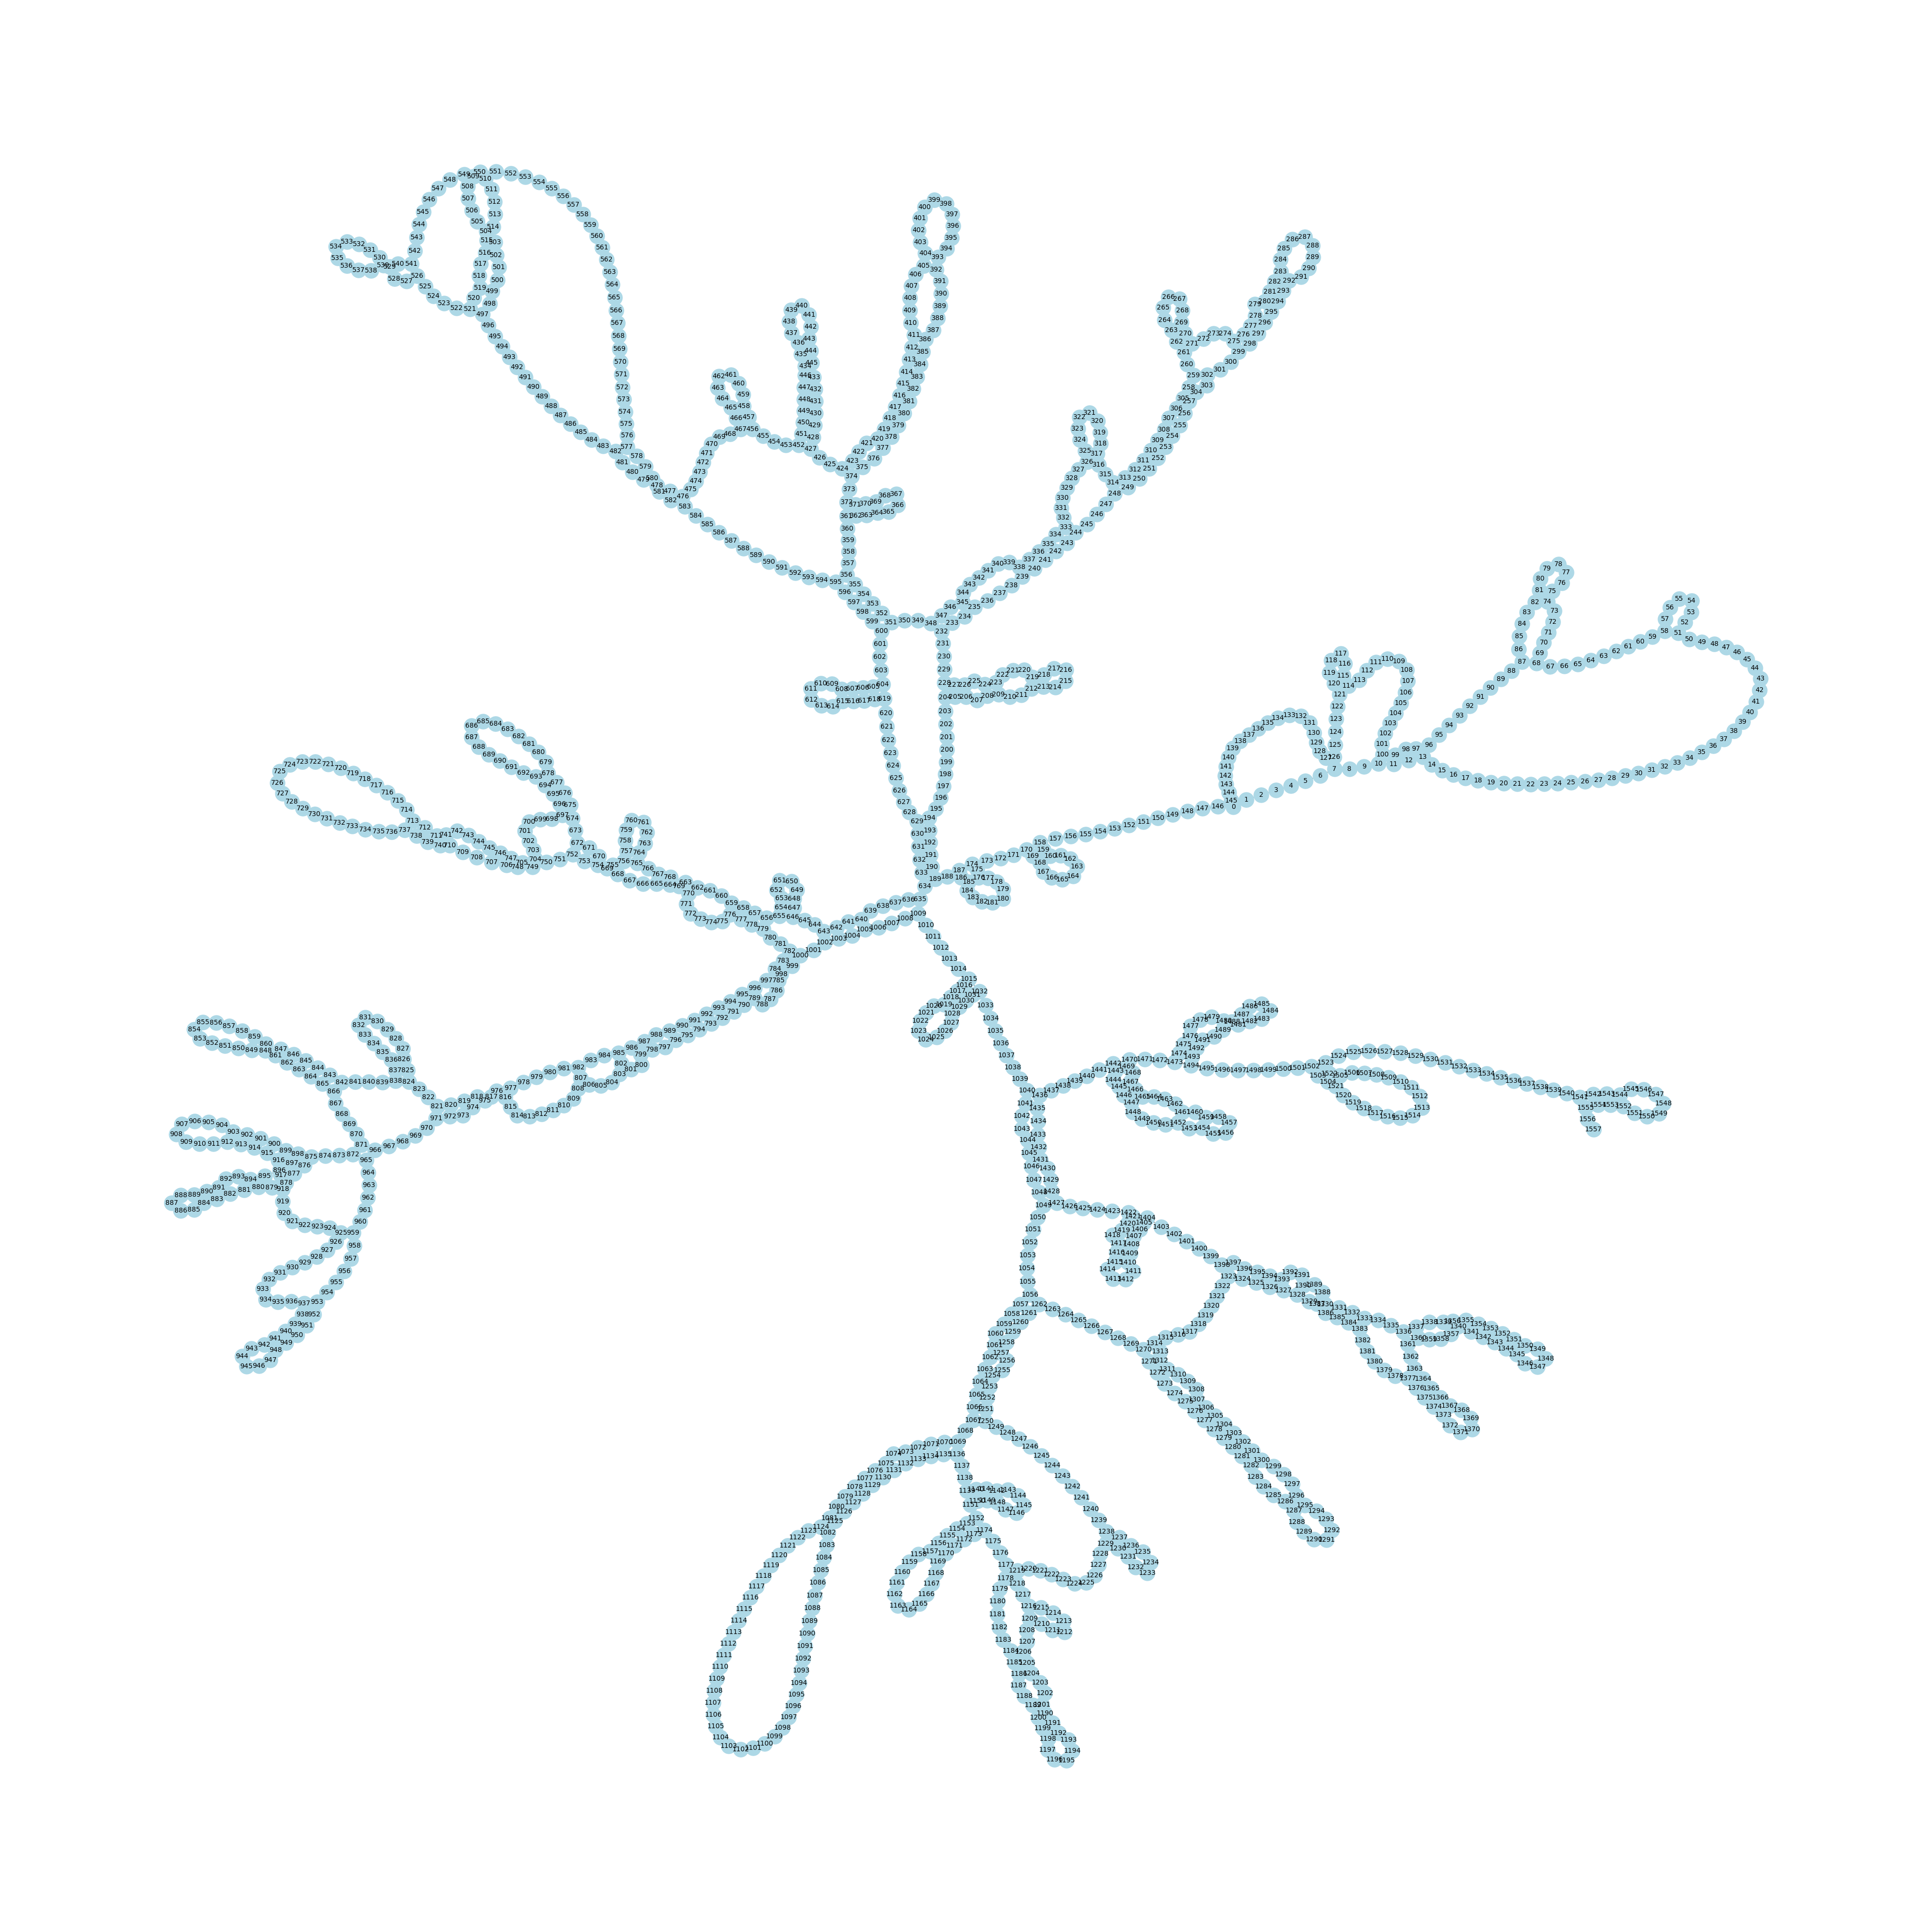

In [26]:
plt.figure(figsize=(40,40))
draw_rna_graph(dot_bracket_to_graph(energy_df.loc["MTRNR2", "ss"]))

In [27]:
nt_2d_distances = {
    gene: nx.floyd_warshall_numpy(dot_bracket_to_graph(energy_df.loc[gene, "ss"]))
    for gene in genes
}
nt_2d_distances

{'MTRNR1': array([[  0.,   1.,   2., ..., 101., 102., 103.],
        [  1.,   0.,   1., ..., 100., 101., 102.],
        [  2.,   1.,   0., ...,  99., 100., 101.],
        ...,
        [101., 100.,  99., ...,   0.,   1.,   2.],
        [102., 101., 100., ...,   1.,   0.,   1.],
        [103., 102., 101., ...,   2.,   1.,   0.]]),
 'MTRNR2': array([[ 0.,  1.,  2., ..., 79., 80., 81.],
        [ 1.,  0.,  1., ..., 80., 81., 82.],
        [ 2.,  1.,  0., ..., 81., 82., 83.],
        ...,
        [79., 80., 81., ...,  0.,  1.,  2.],
        [80., 81., 82., ...,  1.,  0.,  1.],
        [81., 82., 83., ...,  2.,  1.,  0.]])}

In [28]:
mithril_df = mithril_df.join(pd.read_csv("data/PTM.txt", sep="\t", index_col="Mithril_id").modification)
mithril_df

,Start,Ref,Alt,Molecule_type,Gene_symbol,Extended_annotation,Gene_position,Gene_start,Gene_end,Gene_strand,MLC_score,PhastCons_100V,PhyloP_100V,gene,modification
Mithril_id,,,,,,,,,,,,,,,
MITHRIL.1941,648,A,C,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,1,648,1601,+,0.519343,0.016,-1.211,MTRNR1,NaN
MITHRIL.1942,648,A,G,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,1,648,1601,+,0.519343,0.016,-1.211,MTRNR1,NaN
MITHRIL.1943,648,A,T,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,1,648,1601,+,0.519343,0.016,-1.211,MTRNR1,NaN
MITHRIL.1944,649,A,C,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,2,648,1601,+,0.536906,0.984,8.630,MTRNR1,NaN
MITHRIL.1945,649,A,G,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,2,648,1601,+,0.536906,0.984,8.630,MTRNR1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,3228,T,C,rRNA,MT-RNR2,mitochondrially encoded 16S rRNA,1557,1671,3229,+,0.681815,0.000,-1.952,MTRNR2,NaN
MITHRIL.9684,3228,T,G,rRNA,MT-RNR2,mitochondrially encoded 16S rRNA,1557,1671,3229,+,0.681815,0.000,-1.952,MTRNR2,NaN
MITHRIL.9685,3229,T,A,rRNA,MT-RNR2,mitochondrially encoded 16S rRNA,1558,1671,3229,+,0.709337,0.000,-0.833,MTRNR2,NaN


In [29]:
closest_modification_2D = mithril_df[["gene", "Gene_position"]].reset_index().merge(
    mithril_df.loc[~mithril_df.modification.isna(), ["gene", "Gene_position"]].drop_duplicates(),
    on="gene", suffixes=["_query", "_modification"]
).set_index("Mithril_id").apply(
    lambda row:
    nt_2d_distances[row.gene][row["Gene_position_query"]-1, row["Gene_position_modification"]-1],
    axis=1
).groupby(axis=0, level=0).min().rename("closest_modification_2D")
closest_modification_2D

Mithril_id
MITHRIL.1941    68.0
MITHRIL.1942    68.0
MITHRIL.1943    68.0
MITHRIL.1944    67.0
MITHRIL.1945    67.0
                ... 
MITHRIL.9683    63.0
MITHRIL.9684    63.0
MITHRIL.9685    64.0
MITHRIL.9686    64.0
MITHRIL.9687    64.0
Name: closest_modification_2D, Length: 7536, dtype: float64

In [30]:
closest_modification = mithril_df[["gene", "Gene_position"]].reset_index().merge(
    mithril_df.loc[~mithril_df.modification.isna(), ["gene", "Gene_position"]].drop_duplicates(),
    on="gene", suffixes=["_query", "_modification"]
).set_index("Mithril_id")
closest_modification["closest_modification"] = (
    closest_modification["Gene_position_query"] - closest_modification["Gene_position_modification"]
).abs()
closest_modification = closest_modification.groupby(level=0).closest_modification.min()
closest_modification

Mithril_id
MITHRIL.1941    428
MITHRIL.1942    428
MITHRIL.1943    428
MITHRIL.1944    427
MITHRIL.1945    427
               ... 
MITHRIL.9683    160
MITHRIL.9684    160
MITHRIL.9685    161
MITHRIL.9686    161
MITHRIL.9687    161
Name: closest_modification, Length: 7536, dtype: int64

In [31]:
coordinates3D = pd.read_csv("data/structures/residues_3Dcoord.csv", sep="\t").replace({"Ref":{"U":"T"}})
coordinates3D = mithril_df.reset_index().merge(
    coordinates3D,
    on=["gene", "Gene_position"], how="left"
).set_index("Mithril_id")[["x_coord", "y_coord", "z_coord"]]
coordinates3D

,x_coord,y_coord,z_coord
Mithril_id,,,
MITHRIL.1941,74.989870,3.792304,-17.815130
MITHRIL.1942,74.989870,3.792304,-17.815130
MITHRIL.1943,74.989870,3.792304,-17.815130
MITHRIL.1944,78.754455,2.011318,-16.298545
MITHRIL.1945,78.754455,2.011318,-16.298545
...,...,...,...
MITHRIL.9683,-39.321650,77.760650,-31.156100
MITHRIL.9684,-39.321650,77.760650,-31.156100
MITHRIL.9685,-31.769100,74.606700,-33.021850


In [32]:
# check if reference is different in the PDB
mithril_df.merge(
    pd.read_csv("data/structures/residues_3Dcoord.csv", sep="\t").replace({"Ref":{"U":"T"}}),
    on=["gene", "Gene_position"]
).query("Ref_x!=Ref_y")

,Start,Ref_x,Alt,Molecule_type,Gene_symbol,Extended_annotation,Gene_position,Gene_start,Gene_end,Gene_strand,MLC_score,PhastCons_100V,PhyloP_100V,gene,modification,x_coord,y_coord,z_coord,Ref_y


In [33]:
##################################
############## SAVE ##############
##################################

In [34]:
mithril_df[["PhastCons_100V", "PhyloP_100V", "MLC_score"]]\
    .join(closest_modification).join(closest_modification_2D)\
        .join(sequence_features_result).join(energy_df.ddG).join(coordinates3D)\
            .to_csv("checkpoints/mithril_features.csv", sep="\t")
